In [203]:
import torch
import pathlib
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import model as models
import dataset as datasets

plt.style.use("seaborn-v0_8-darkgrid")

In [ ]:
checkpoints_model = sorted(list(pathlib.Path("./checkpoints/").glob("*-model.pth")))
checkpoints_history = sorted(list(pathlib.Path("./checkpoints/").glob("*-history.pth")))
checkpoints_model

[PosixPath('checkpoints/LightViT54M-T1-E016-model.pth'),
 PosixPath('checkpoints/LightViT54M-T1-E032-model.pth'),
 PosixPath('checkpoints/LightViT54M-T1-E048-model.pth'),
 PosixPath('checkpoints/LightViT54M-T1-E064-model.pth'),
 PosixPath('checkpoints/LightViT54M-T1-E080-model.pth'),
 PosixPath('checkpoints/LightViT54M-T1-E096-model.pth'),
 PosixPath('checkpoints/LightViT54M-T1-E112-model.pth'),
 PosixPath('checkpoints/LightViT54M-T1-E128-model.pth'),
 PosixPath('checkpoints/LightViT54M-T1-ELAT-model.pth')]

In [6]:
history = torch.load(checkpoints_history[-1], map_location="cpu")
history.keys()

dict_keys(['raw_batch_loss', 'avg_batch_loss', 'pred_match', 'pred_count', 'avg_batch_accuracy', 'avg_epoch_accuracy', 'learning_rate'])

In [9]:
dataframe_train, dataframe_test = datasets.make_train_test_split(pathlib.Path("/opt/datasets/imagenet-256-dimensi0n/"), random_state=128)

dataset_train = datasets.ImageNetDataset(dataframe=dataframe_train, transform=datasets.transform_extra)
dataset_test = datasets.ImageNetDataset(dataframe=dataframe_test, transform=datasets.transform_basic)

dataloader_train = torch.utils.data.DataLoader(
    dataset=dataset_train,
    batch_size=64+32+4,
    shuffle=True,
    num_workers=8
)

dataloader_test = torch.utils.data.DataLoader(
    dataset=dataset_test,
    batch_size=512,
    shuffle=False,
    num_workers=8
)

len(dataset_train), len(dataset_test), len(dataloader_train), len(dataloader_test)

(404869, 134957, 4049, 264)

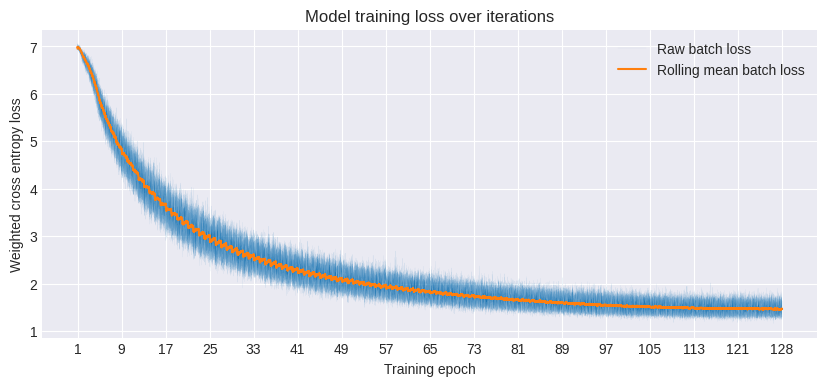

In [183]:
plt.figure(figsize=(10, 4))
plt.title("Model training loss over iterations")
plt.plot(history["raw_batch_loss"], linewidth=0.03, label="Raw batch loss")
plt.plot(history["avg_batch_loss"], label="Rolling mean batch loss")
plt.ylabel("Weighted cross entropy loss")
plt.xlabel("Training epoch")
plt.xticks(list(range(len(history["raw_batch_loss"])))[::len(dataloader_train)*8] + [len(history["avg_batch_accuracy"])], list(range(1, 128+1, 8)) + [128])
plt.legend()
plt.show()

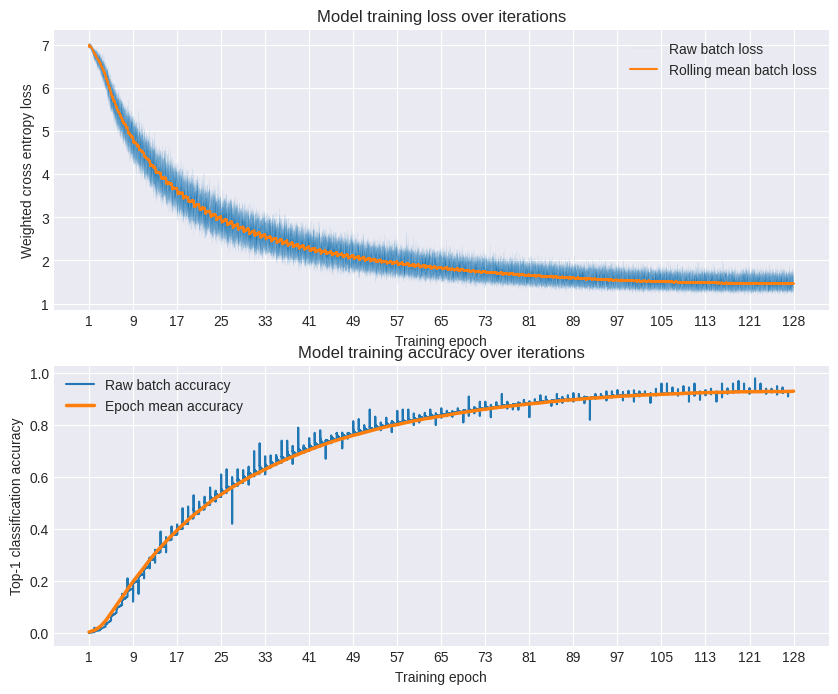

In [187]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.title("Model training loss over iterations")
plt.plot(history["raw_batch_loss"], linewidth=0.03, label="Raw batch loss")
plt.plot(history["avg_batch_loss"], label="Rolling mean batch loss")
plt.ylabel("Weighted cross entropy loss")
plt.xlabel("Training epoch")
plt.xticks(list(range(len(history["raw_batch_loss"])))[::len(dataloader_train)*8] + [len(history["avg_batch_accuracy"])], list(range(1, 128+1, 8)) + [128])
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Model training accuracy over iterations")
plt.plot(history["avg_batch_accuracy"], label="Raw batch accuracy")
plt.plot(F.interpolate(
    torch.tensor([[history["avg_epoch_accuracy"]]]), size=(len(history["avg_batch_accuracy"])),
    mode="linear", align_corners=True
).squeeze(), linewidth=2.5, label="Epoch mean accuracy")
plt.ylabel("Top-1 classification accuracy")
plt.xlabel("Training epoch")
plt.xticks(list(range(len(history["avg_batch_accuracy"])))[::len(dataloader_train)*8] + [len(history["avg_batch_accuracy"])], list(range(1, 128+1, 8)) + [128])
plt.legend()

plt.show()

In [11]:
X_batch, y_batch = next(iter(dataloader_test))
X_batch.shape, y_batch.shape

(torch.Size([512, 3, 256, 256]), torch.Size([512]))

In [27]:
def predict(model, dataloader, max_batch=None, device="cuda"):
    model.eval()
    torch.cuda.empty_cache()
    y_pred, y_true = [], []

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader, 1):
            try:
                y_logits = model(X.to(device))
                y_pred += y_logits.argmax(dim=1).tolist()
                y_true += y.tolist()
                print(f"* Evaluating {batch}/{max_batch or len(dataloader)}", end="\r")
                if max_batch and batch >= max_batch: break
            except:
                break
    print(end="\n")

    return torch.tensor(y_pred), torch.tensor(y_true)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.LightViTClassifier(
    target_resolution=(256, 256),
    num_classes=len(dataset_train.class_to_idx),
    num_patches=(16, 16),
    embedding_dim=512,
    num_layers=16,
    num_heads=8,
    dropout_p=0.1,
    in_channels=3
).to(device)

model.load_state_dict(torch.load(
    f=checkpoints_model[-1],
    map_location=device
))

<All keys matched successfully>

In [ ]:
model_predictions = []
for point in checkpoints_model:
    model.load_state_dict(torch.load(f=point, map_location=device))
    y_pred, y_true = predict(model, dataloader_test, max_batch=None, device=device)
    model_predictions.append(torch.stack([y_pred, y_true], dim=0))

* Evaluating 264/264
* Evaluating 264/264
* Evaluating 264/264
* Evaluating 264/264
* Evaluating 264/264
* Evaluating 264/264
* Evaluating 264/264
* Evaluating 264/264
* Evaluating 264/264


In [ ]:
accuracies = (torch.stack(model_predictions)[:, 0, :] == torch.stack(model_predictions)[:, 1, :]).sum(dim=1) / len(dataframe_test)

print("Test accuracies for all checkpoints:")
for point, accuracy in zip(checkpoints_model, accuracies):
    print(f"- {point.stem[:-6]} - {round(accuracy.item()*100)}%")

Test accuracies for all checkpoints:
- LightViT54M-T1-E016 - 44%
- LightViT54M-T1-E032 - 59%
- LightViT54M-T1-E048 - 63%
- LightViT54M-T1-E064 - 66%
- LightViT54M-T1-E080 - 67%
- LightViT54M-T1-E096 - 69%
- LightViT54M-T1-E112 - 69%
- LightViT54M-T1-E128 - 70%
- LightViT54M-T1-ELAT - 70%


Text(0, 0.5, 'Model checkpoint')

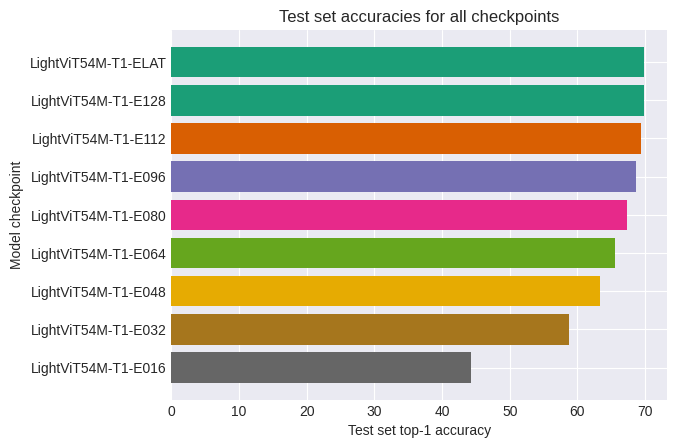

In [218]:
plt.title("Test set accuracies for all checkpoints")
plt.barh(
    y=[str(model.stem[:-6]) for model in checkpoints_model],
    width=accuracies*100,
    color=plt.cm.Dark2_r(np.linspace(0, 1, len(accuracies)))
)
plt.xlabel("Test set top-1 accuracy")
plt.ylabel("Model checkpoint")